# MHR mesh + keypoints — 3D scatter
Runs the MHR model with controllable parameters and visualises vertices and joint positions.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import torch
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ── Load MHR ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

try:
    from momentum import MHR
    mhr = MHR.from_files(folder=Path('/scratch/cq244/MHR/assets'), device=device, lod=1)
    print('Loaded MHR via momentum package')
except Exception:
    mhr = torch.jit.load('/scratch/cq244/MHR/assets/mhr_model.pt', map_location=device)
    print('Loaded MHR via TorchScript')

for p in mhr.parameters():
    p.requires_grad_(False)

Using device: cuda
Loaded MHR via TorchScript


In [3]:
# ── Parameters ────────────────────────────────────────────────────────────────
B = 1

# model_params: [transl(3)*10 | global_rot(3) | body_pose(130)] = 136, then scales(68) appended → 204
# transl is in metres * 10 inside model_params (see mhr_head.py:214)

transl_m   = torch.zeros(B, 3, device=device)        # metres — set to 0
global_rot = torch.zeros(B, 3, device=device)        # euler xyz
body_pose  = torch.zeros(B, 130, device=device)      # body pose
shape_params = torch.zeros(B, 45, device=device)     # shape
expr_params  = torch.zeros(B, 72, device=device)     # expression

# Default scale: replicate what mhr_head uses (scale_mean + 0 * scale_comps)
# We'll just pass zeros and rely on MHR defaults; adjust if needed
scales = torch.zeros(B, 68, device=device)

model_params = torch.cat([
    transl_m * 10,   # MHR expects translation in units of 10*metres
    global_rot,
    body_pose,
    scales,
], dim=1)  # (B, 204)

print(f'model_params shape: {model_params.shape}')

model_params shape: torch.Size([1, 204])


In [4]:
# ── Forward pass ──────────────────────────────────────────────────────────────
with torch.no_grad():
    verts_raw, skel_state = mhr(shape_params, model_params, expr_params)

joint_coords, joint_quats, _ = torch.split(skel_state, [3, 4, 1], dim=2)

verts  = (verts_raw  / 100).squeeze(0).cpu().numpy()   # (N_verts, 3) metres
joints = (joint_coords / 100).squeeze(0).cpu().numpy() # (N_joints, 3) metres

print(f'Vertices : {verts.shape}   range Z: [{verts[:,2].min():.3f}, {verts[:,2].max():.3f}]')
print(f'Joints   : {joints.shape}')
print(f'Joint 0 (root)  : {joints[0]}')
print(f'Joint 1 (pelvis): {joints[1]}')

Vertices : (18439, 3)   range Z: [-0.139, 0.256]
Joints   : (127, 3)
Joint 0 (root)  : [0. 0. 0.]
Joint 1 (pelvis): [0.       0.923987 0.      ]


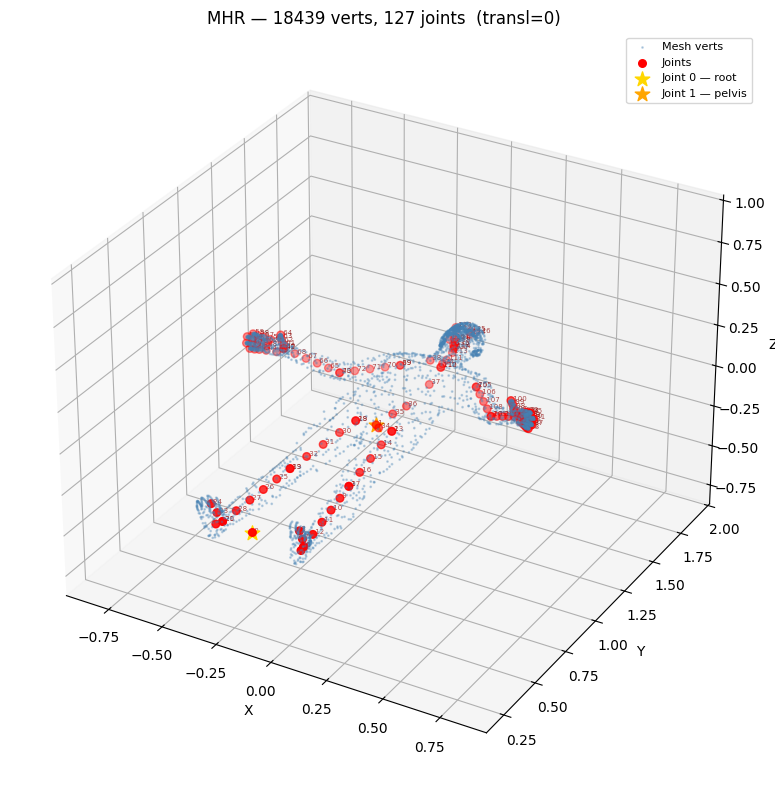

In [5]:
# ── Subsample verts for scatter ───────────────────────────────────────────────
def subsample(pts, n=3000):
    idx = np.linspace(0, len(pts) - 1, min(n, len(pts)), dtype=int)
    return pts[idx]

verts_s = subsample(verts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.scatter(verts_s[:, 0], verts_s[:, 1], verts_s[:, 2],
           c='steelblue', s=1, alpha=0.3, label='Mesh verts')
ax.scatter(joints[:, 0], joints[:, 1], joints[:, 2],
           c='red', s=30, zorder=5, label='Joints')
ax.scatter(*joints[0], c='gold',   s=120, marker='*', zorder=6, label='Joint 0 — root')
ax.scatter(*joints[1], c='orange', s=120, marker='*', zorder=6, label='Joint 1 — pelvis')
for i, j in enumerate(joints):
    ax.text(j[0], j[1], j[2], f' {i}', fontsize=5, color='darkred', alpha=0.7)

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'MHR — {len(verts)} verts, {len(joints)} joints  (transl=0)')
ax.legend(fontsize=8)

all_pts = np.vstack([verts_s, joints])
mid = all_pts.mean(0)
r   = (all_pts.max(0) - all_pts.min(0)).max() / 2 * 1.1
ax.set_xlim(mid[0]-r, mid[0]+r)
ax.set_ylim(mid[1]-r, mid[1]+r)
ax.set_zlim(mid[2]-r, mid[2]+r)

plt.tight_layout()
plt.show()
# out = 'mhr_zero_pose.png'
# fig.savefig(out, dpi=150)
# print(f'Saved → {out}')

tensor([[ 1.4640, -0.3238,  0.7740]], device='cuda:0')
Random params — joint 0: [0. 0. 0.]  (should be [0,0,0])
Random params — joint 1: [0.14639567 0.8916028  0.07739644]
Saved → mhr_random_pose.png


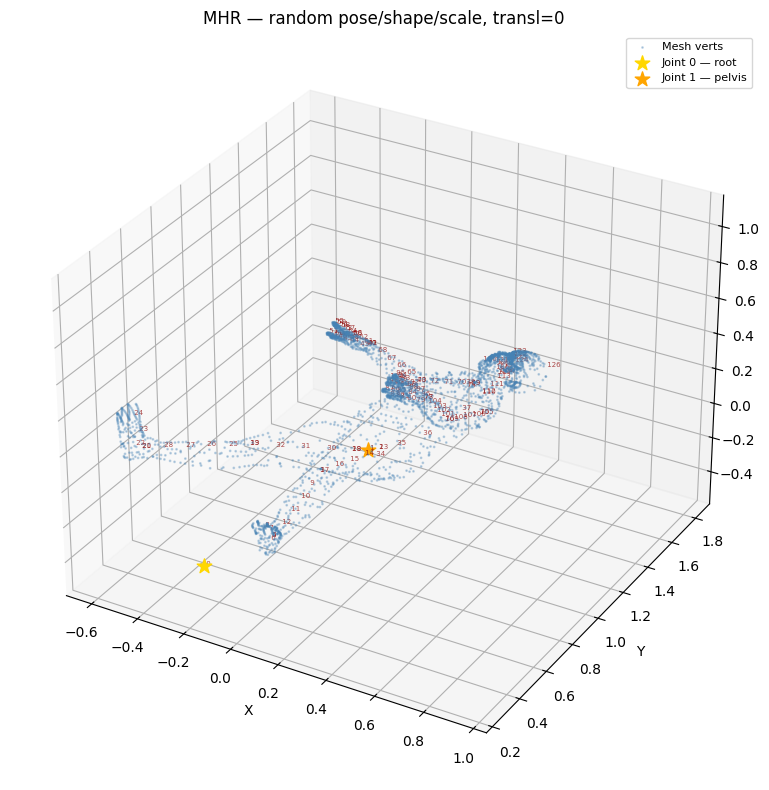

In [12]:
# ── Experiment: randomise pose/shape, keep transl=0 ──────────────────────────
torch.manual_seed(42)
B2 = 1

shape_r  = torch.randn(B2, 45, device=device) * 0.5
expr_r   = torch.randn(B2, 72, device=device) * 0.3
pose_r   = torch.randn(B2, 130, device=device) * 0.2
rot_r    = torch.randn(B2, 3,   device=device) * 0.3
scale_r  = torch.randn(B2, 68,  device=device) * 0.1

transl_r = torch.randn(B2, 3, device=device)
print(transl_r)

mp_r = torch.cat([transl_r, rot_r, pose_r, scale_r], dim=1)

with torch.no_grad():
    vr, sr = mhr(shape_r, mp_r, expr_r)

jc_r, _, _ = torch.split(sr, [3, 4, 1], dim=2)
joints_r = (jc_r / 100).squeeze(0).cpu().numpy()
verts_r  = (vr   / 100).squeeze(0).cpu().numpy()

print(f'Random params — joint 0: {joints_r[0]}  (should be [0,0,0])')
print(f'Random params — joint 1: {joints_r[1]}')

fig2 = plt.figure(figsize=(10, 8))
ax2  = fig2.add_subplot(111, projection='3d')
ax2.scatter(*subsample(verts_r).T,  c='steelblue', s=1, alpha=0.3, label='Mesh verts')
# ax2.scatter(*joints_r.T,            c='red',    s=30, zorder=5, label='Joints')
ax2.scatter(*joints_r[0],           c='gold',   s=120, marker='*', zorder=6, label='Joint 0 — root')
ax2.scatter(*joints_r[1],           c='orange', s=120, marker='*', zorder=6, label='Joint 1 — pelvis')
for i, j in enumerate(joints_r):
    ax2.text(j[0], j[1], j[2], f' {i}', fontsize=5, color='darkred', alpha=0.7)
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.set_title('MHR — random pose/shape/scale, transl=0')
ax2.legend(fontsize=8)
all2 = np.vstack([subsample(verts_r), joints_r])
mid2 = all2.mean(0); r2 = (all2.max(0)-all2.min(0)).max()/2*1.1
ax2.set_xlim(mid2[0]-r2, mid2[0]+r2)
ax2.set_ylim(mid2[1]-r2, mid2[1]+r2)
ax2.set_zlim(mid2[2]-r2, mid2[2]+r2)
plt.tight_layout()
out2 = 'mhr_random_pose.png'
fig2.savefig(out2, dpi=150)
print(f'Saved → {out2}')